# Introduction
In this notebook we will compare custom and default rewards focusing on dqn.
- Default rewards:   "collision_reward": -1,  "right_lane_reward": 0.1, "high_speed_reward": 0.4,
- Custom rewards: "collision_reward": -0.4, "right_lane_reward": 0.1, "high_speed_reward": 0.5,
# Why?
We have reused the collision penalty and increased the speed reward. The goal is to get the actor to take more risks, drive faster and overtake more.

# Training
- Default: It was trained for 55k timestamps uninterrupted. Total training time: 16 h
- Custom: The custom was trained initially for 20k timestamps and then fine-tuned. From 20-40 and from 40-60k. Total training time: 6 h

### A note on fine-tuning:
Since every time the training started the exploration rate resets the resulting model has explored a lot more but possibly doesn't have enough time to stabilise. The result may be a bit more jittery. The time is way less. 
  

In [87]:
import gymnasium
import numpy as np
from stable_baselines3 import DQN
import matplotlib.pyplot as plt
import torch


In [88]:
# Check device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


In [89]:



def evaluate_model(model, env, num_episodes=10, device="cpu"):
    """Evaluates a model in the given environment."""
    episode_lengths = []
    episode_rewards = []
    average_speeds = []
    total_collisions = 0  # Keep track of total collisions across all episodes

    for episode in range(num_episodes):
        obs = env.reset()[0]

        # Move observation to GPU if CUDA is available
        if device == "cuda":
            obs = torch.tensor(obs, device=device)

        done = False
        total_reward = 0
        length = 0
        total_speed = 0
        collisions = 0  # Reset per episode

        while not done:
            # Predict the action
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            total_reward += reward
            length += 1

            # Collect speed from info (assuming it's available)
            if "speed" in info:
                total_speed += info["speed"]

            # Check for collisions (assuming collisions info is available)
            if "crashed" in info and info["crashed"]:
                collisions += 1

            # Debugging: Print the info dictionary to see its structure
            # print(info)  # Uncomment this line to inspect info

        # Store results per episode
        episode_lengths.append(length)
        episode_rewards.append(total_reward)
        average_speeds.append(total_speed / length if length > 0 else 0)
        total_collisions += collisions

        # Print message when episode is done
        print(
            f"Episode {episode + 1}/{num_episodes} completed. Length: {length}, Total Reward: {total_reward}, Collisions: {collisions}")

    return {
        "episode_lengths": np.array(episode_lengths),
        "episode_rewards": np.array(episode_rewards),
        "average_speeds": np.array(average_speeds),
        "total_collisions": total_collisions,  # Return total collisions across all episodes
    }


In [90]:
# Load the two trained models
model1_path = "./logs/history/default/rl_model_dqn_55000_steps.zip"  # Replace with your model 1 path
model2_path = "./logs/history/speed_05_lane01_coll_04/finetune/rl_model_dqn_60000_steps.zip"  # Replace with your model 2 path

default = DQN.load(model1_path, device=device)
custom = DQN.load(model2_path, device=device)

 Each model is tested in the environment it was trained. Only difference is the reward function. We look at the reward, speed and time. 

In [91]:
# Create the environment
# Register and create the custom environment
from gymnasium import register

register(
    id='HighwayEnvFast-v0',
    entry_point='highway_env.envs:HighwayEnv',
)

env1 = gymnasium.make("HighwayEnvFast-v0")
# Register the custom environment


# Configure the environment
env1.unwrapped.config.update({
    "lanes_count": 4,  # Number of lanes
    "vehicles_count": 100,  # Ensure a high number of vehicles
    "controlled_vehicles": 1,  # Number of ego vehicles
    "duration": 100,  # Episode duration
    "reward_speed_range": [20, 30],  # Speed reward range
    "vehicles_density": 1.0,  # Increase density for more consistent presence
    "spawn_probability": 1.0,  # Ensure continuous vehicle spawning
})

# Evaluate both models
results_model1 = evaluate_model(default, env1)
env1.close()

# Create the environment
register(
    id='CustomRewardEnv',
    entry_point='HighwayEnvCustomReward:HighwayEnvFastCustomReward',
)

env2 = gymnasium.make("CustomRewardEnv")

env2.unwrapped.config.update({
    "lanes_count": 4,  # Number of lanes
    "vehicles_count": 100,  # Ensure a high number of vehicles
    "controlled_vehicles": 1,  # Number of ego vehicles
    "duration": 100,  # Episode duration
    "reward_speed_range": [20, 30],  # Speed reward range
    "vehicles_density": 1.0,  # Increase density for more consistent presence
    "spawn_probability": 1.0,  # Ensure continuous vehicle spawning
})

results_model2 = evaluate_model(custom, env2)

# Close the environment

env2.close()


C:\Users\margi\PycharmProjects\selfdrivingcar\.venv\Lib\site-packages\gymnasium\envs\registration.py:642: UserWarning: WARN: Overriding environment HighwayEnvFast-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
C:\Users\margi\PycharmProjects\selfdrivingcar\.venv\Lib\site-packages\gymnasium\envs\registration.py:642: UserWarning: WARN: Overriding environment HighwayFastCustomReward-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


Episode 1/10 completed. Length: 100, Total Reward: 85.60774605157796, Collisions: 0
Episode 2/10 completed. Length: 20, Total Reward: 18.165280032634943, Collisions: 1
Episode 3/10 completed. Length: 54, Total Reward: 46.12364583916857, Collisions: 1
Episode 4/10 completed. Length: 69, Total Reward: 62.47983704538617, Collisions: 1
Episode 5/10 completed. Length: 100, Total Reward: 82.84892822762288, Collisions: 0
Episode 6/10 completed. Length: 36, Total Reward: 34.07263573073196, Collisions: 1
Episode 7/10 completed. Length: 58, Total Reward: 43.00071948341215, Collisions: 1
Episode 8/10 completed. Length: 37, Total Reward: 34.60888101369381, Collisions: 1
Episode 9/10 completed. Length: 94, Total Reward: 75.49913373956761, Collisions: 1
Episode 10/10 completed. Length: 45, Total Reward: 38.932388791660955, Collisions: 1
Episode 1/10 completed. Length: 100, Total Reward: 49.4793048973114, Collisions: 0
Episode 2/10 completed. Length: 100, Total Reward: 49.37069510268561, Collisions: 

In [92]:
# Compare results
# Compare results
print("Default Performance:")
print(f"Average Episode Length: {results_model1['episode_lengths'].mean()}")
print(f"Average Episode Reward: {results_model1['episode_rewards'].mean()}")
print(f"Average Speed: {results_model1['average_speeds'].mean()}")
print(f"Total Collisions: {results_model1['total_collisions']}")

print("Custom Performance:")
print(f"Average Episode Length: {results_model2['episode_lengths'].mean()}")
print(f"Average Episode Reward: {results_model2['episode_rewards'].mean()}")
print(f"Average Speed: {results_model2['average_speeds'].mean()}")
print(f"Total Collisions: {results_model2['total_collisions']}")

Default Performance:
Average Episode Length: 61.3
Average Episode Reward: 52.13391959554569
Average Speed: 26.263615433351738
Total Collisions: 8
Custom Performance:
Average Episode Length: 75.3
Average Episode Reward: 37.33620628812107
Average Speed: 28.9590785600844
Total Collisions: 5


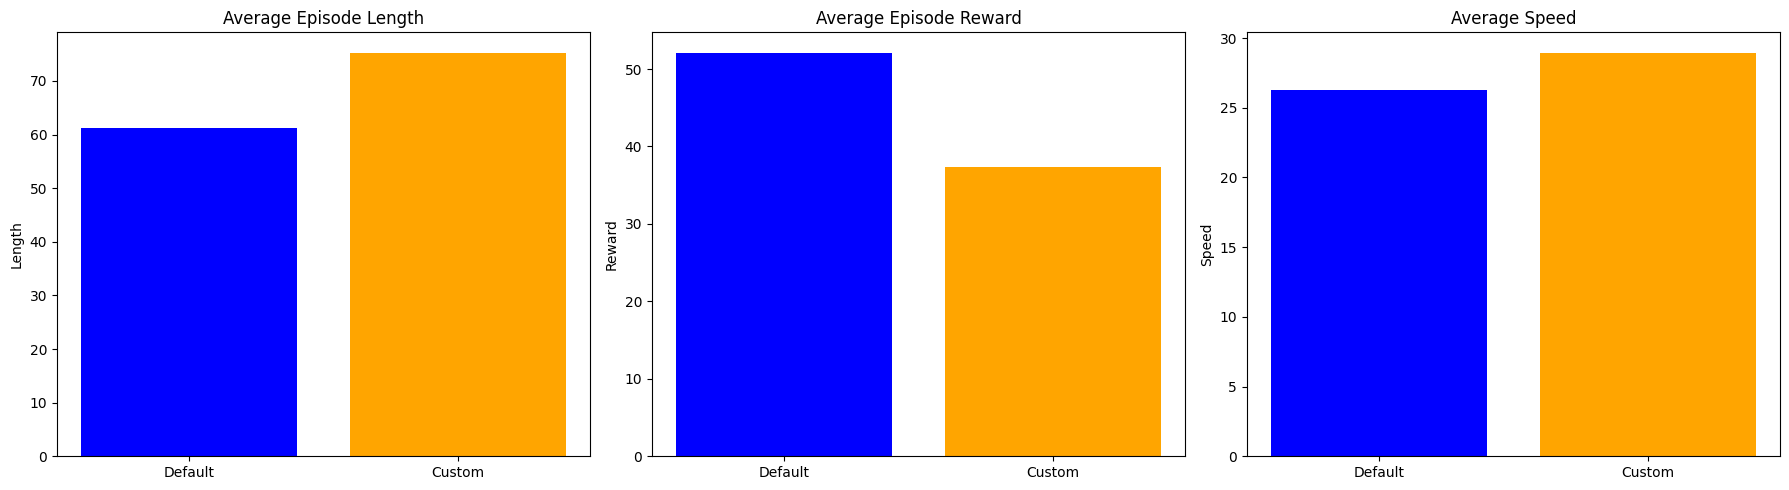

In [93]:

# Plot comparisons
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Episode Length Comparison
axs[0].bar(["Default", "Custom"],
           [results_model1['episode_lengths'].mean(), results_model2['episode_lengths'].mean()],
           color=['blue', 'orange'])
axs[0].set_title("Average Episode Length")
axs[0].set_ylabel("Length")

# Episode Reward Comparison
axs[1].bar(["Default", "Custom"],
           [results_model1['episode_rewards'].mean(), results_model2['episode_rewards'].mean()],
           color=['blue', 'orange'])
axs[1].set_title("Average Episode Reward")
axs[1].set_ylabel("Reward")

# Average Speed Comparison
axs[2].bar(["Default", "Custom"],
           [results_model1['average_speeds'].mean(), results_model2['average_speeds'].mean()],
           color=['blue', 'orange'])
axs[2].set_title("Average Speed")
axs[2].set_ylabel("Speed")

plt.tight_layout()
plt.show()


Here we see that the custom reward function results in fewer collisions, longer episodes, and faster driving. The default reward function, while yielding higher rewards, does not lead to better performance. Despite more rewards, it encourages behaviors that result in crashes or inefficient driving. This shows that the default reward function is flawed because it prioritizes short-term rewards without considering long-term goals like safety and efficiency, whereas the custom reward function aligns better with these objectives

In [94]:

# Additional Metrics (Optional)
def summarize_results(results):
    print(f"Mean Episode Length: {results['episode_lengths'].mean():.2f}")
    print(f"Std Dev of Episode Length: {results['episode_lengths'].std():.2f}")
    print(f"Mean Episode Reward: {results['episode_rewards'].mean():.2f}")
    print(f"Std Dev of Episode Reward: {results['episode_rewards'].std():.2f}")


print("\nDetailed Results for Default:")
summarize_results(results_model1)

print("\nDetailed Results for Custom:")
summarize_results(results_model2)



Detailed Results for Default:
Mean Episode Length: 61.30
Std Dev of Episode Length: 27.18
Mean Episode Reward: 52.13
Std Dev of Episode Reward: 21.90

Detailed Results for Custom:
Mean Episode Length: 75.30
Std Dev of Episode Length: 27.74
Mean Episode Reward: 37.34
Std Dev of Episode Reward: 14.23
